<!-- Imports and Setup -->
<!-- to load tools -->

In [57]:
# Cell 1: Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, f1_score, confusion_matrix, classification_report
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore') # Keeps your notebook clean from warnings

<!-- Data Loading & Stratified Split -->
<!-- the data preparation -->

In [58]:
# Cell 2: Data Prep
# NOTE: To run the other dataset, change to 'Fraud_Data.csv' and 'class'
DATA_FILE = '../data/raw/creditcard.csv' 
TARGET_COL = 'Class'

print(f"Loading {DATA_FILE}...")
df = pd.read_csv(DATA_FILE)

# Separate features and target
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Stratified Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print(f"Fraud cases in test set: {sum(y_test == 1)}")

Loading ../data/raw/creditcard.csv...
Training data shape: (227845, 30)
Testing data shape: (56962, 30)
Fraud cases in test set: 98


Baseline Model (Logistic Regression)
This trains your interpretable baseline model and evaluates it using Cross-Validation.

In [59]:
# Cell 3: Baseline Model
print("Training Baseline: Logistic Regression...")

# Initialize with balanced class weights
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Set up Stratified K-Fold for reliable cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run Cross-Validation
scoring_metrics = ['f1', 'average_precision']
cv_results_lr = cross_validate(log_reg, X_train, y_train, cv=cv, scoring=scoring_metrics)

print(f"CV F1-Score: {np.mean(cv_results_lr['test_f1']):.4f} (+/- {np.std(cv_results_lr['test_f1']):.4f})")
print(f"CV AUC-PR: {np.mean(cv_results_lr['test_average_precision']):.4f} (+/- {np.std(cv_results_lr['test_average_precision']):.4f})")

# Fit on the full training set and predict on the holdout test set
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

Training Baseline: Logistic Regression...
CV F1-Score: 0.0973 (+/- 0.0087)
CV AUC-PR: 0.7534 (+/- 0.0496)


<!-- Ensemble Model (XGBoost) with Basic Tuning
This builds your advanced model and handles the heavy imbalance mathematically. -->

In [60]:
# Cell 4: XGBoost Ensemble
print("Training Ensemble: XGBoost...")

# Calculate scale_pos_weight to handle extreme imbalance
neg_class = y_train.value_counts()[0]
pos_class = y_train.value_counts()[1]
scale_weight = neg_class / pos_class

xgb_model = xgb.XGBClassifier(scale_pos_weight=scale_weight, eval_metric='logloss', random_state=42)

# Basic Hyperparameter Grid (Kept small so it runs relatively quickly in a notebook)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5]
}

# Grid Search with CV
grid_search = GridSearchCV(
    estimator=xgb_model, 
    param_grid=param_grid, 
    cv=cv, 
    scoring='average_precision', # Optimize for AUC-PR
    n_jobs=-1 # Uses all available CPU cores
)

grid_search.fit(X_train, y_train)
best_xgb = grid_search.best_estimator_

print(f"Best XGBoost Params: {grid_search.best_params_}")

# Predict on holdout test set
y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

Training Ensemble: XGBoost...
Best XGBoost Params: {'max_depth': 5, 'n_estimators': 100}


Final Evaluation & Model Comparison
This generates the side-by-side comparison table you need for your deliverables.

In [61]:
# Cell 5: Model Evaluation Table
print("--- Final Test Set Evaluation ---")

# 1. Build the list flatly on individual lines to avoid indentation bugs
models_to_check = []
models_to_check.append(("Logistic Regression", y_pred_lr, y_proba_lr))
models_to_check.append(("XGBoost", y_pred_xgb, y_proba_xgb))

results = []

# 2. Run the evaluation loop
for model_name, y_pred, y_proba in models_to_check:
    auc_pr = average_precision_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    results.append({
        "Model": model_name,
        "AUC-PR": round(auc_pr, 4),
        "F1-Score": round(f1, 4),
        "True Negatives": cm[0, 0],
        "False Positives": cm[0, 1],
        "False Negatives": cm[1, 0],
        "True Positives": cm[1, 1]
    })

# 3. Convert and display the final summary table
results_df = pd.DataFrame(results)
results_df

--- Final Test Set Evaluation ---


,Model,AUC-PR,F1-Score,True Negatives,False Positives,False Negatives,True Positives
0,Logistic Regression,0.7233,0.0873,54990,1874,8,90
1,XGBoost,0.8721,0.8542,56852,12,16,82


In the code scripts for Task 2 and Task 3, we trained the models and analyzed them entirely within the computer's temporary memory (RAM). Because we never explicitly instructed Python to write those models to the hard drive, the model folder remains empty.

If we close the Jupyter Notebook right now, those trained models will be lost, and you would have to re-train them from scratch.

The Fix: Add a Model Saving Cell
To save the trained models to the project directory, create a new cell right after the Task 2 training code (or at the very end of the notebook) and run the following script.

We will use the joblib library, which is the standard, highly efficient way to save Scikit-Learn and XGBoost models in Python.

In [62]:
# Cell: Save Trained Models to Disk
import os
import joblib

# 1. Define the directory path where you want to save the models
MODEL_DIR = '../models'

# 2. Create the directory if it doesn't exist yet
os.makedirs(MODEL_DIR, exist_ok=True)

print(f"Ensuring '{MODEL_DIR}/' directory exists...")

# 3. Save the Baseline Logistic Regression Model
lr_filename = os.path.join(MODEL_DIR, 'logistic_regression_baseline.pkl')
joblib.dump(log_reg, lr_filename)
print(f"Saved Baseline Model to: {lr_filename}")

# 4. Save the Best Tuned XGBoost Model
xgb_filename = os.path.join(MODEL_DIR, 'xgboost_best_model.pkl')
joblib.dump(best_xgb, xgb_filename)
print(f"Saved Ensemble Model to: {xgb_filename}")

print("\n--- Current contents of the model folder ---")
print(os.listdir(MODEL_DIR))

Ensuring '../models/' directory exists...
Saved Baseline Model to: ../models\logistic_regression_baseline.pkl
Saved Ensemble Model to: ../models\xgboost_best_model.pkl

--- Current contents of the model folder ---
['logistic_baseline_credit_card.joblib', 'logistic_baseline_ecommerce.joblib', 'logistic_regression_baseline.pkl', 'xgboost_best_model.pkl', 'xgboost_tuned_credit_card.joblib', 'xgboost_tuned_ecommerce.joblib']


While building the model (Task 2) proves how well it works, Model Explainability (Task 3) proves why it works. This is what you will actually present to business stakeholders.

The Python Code for Explainability
This code assumes you are continuing from Task 2 and have your trained model (e.g., best_xgb), your test features (X_test), your true labels (y_test), and your model's predictions (y_pred).

Generating Built-in Feature Importance...


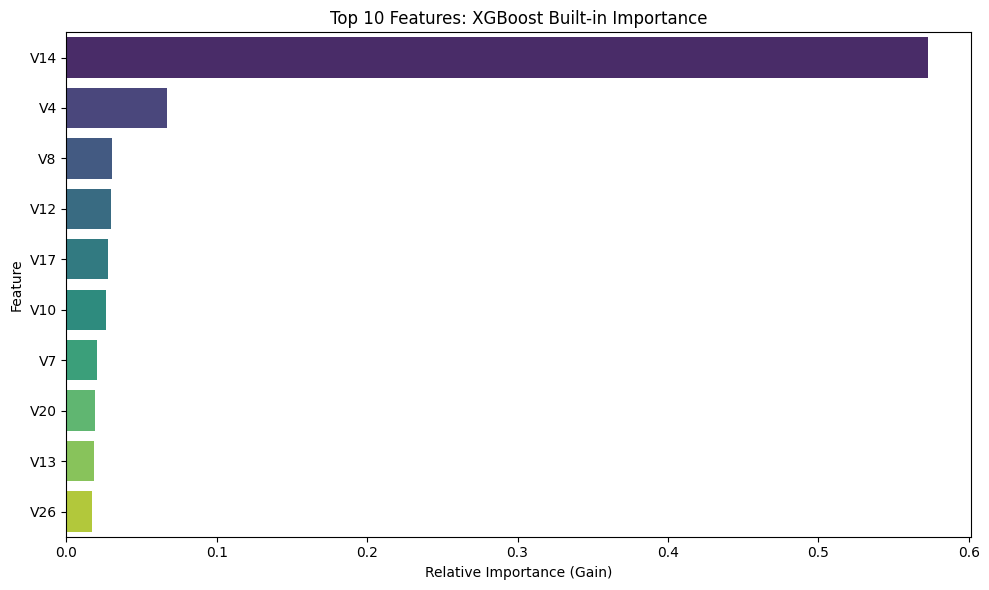

Calculating SHAP values (this may take a moment)...


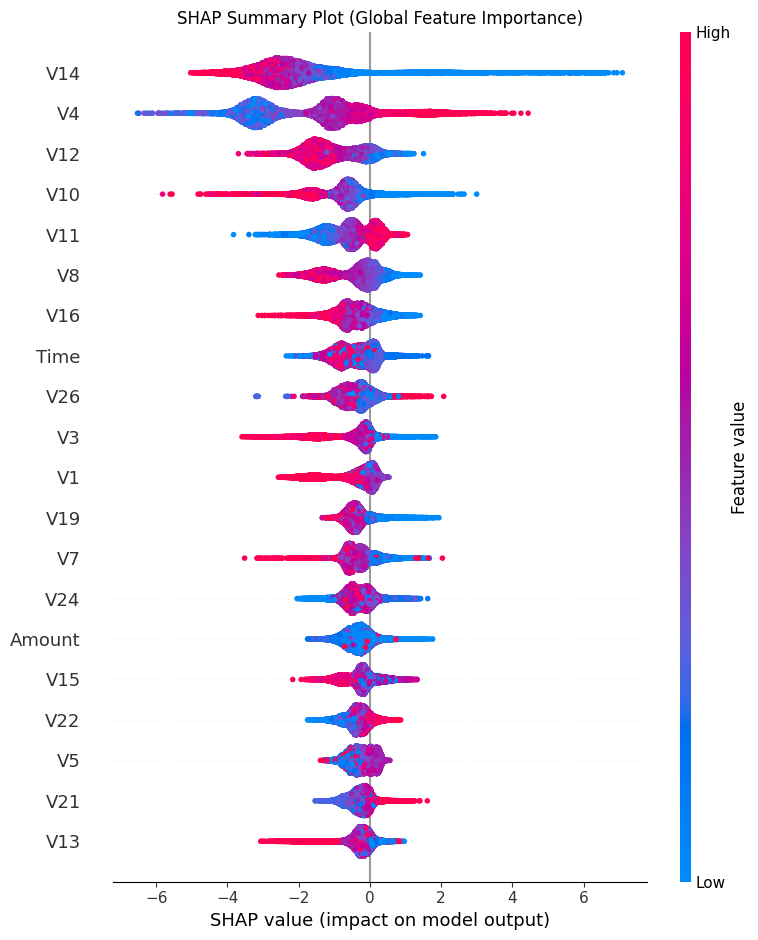

Generating Force Plot for: True Positive (Correctly Flagged Fraud) (Index: 840)


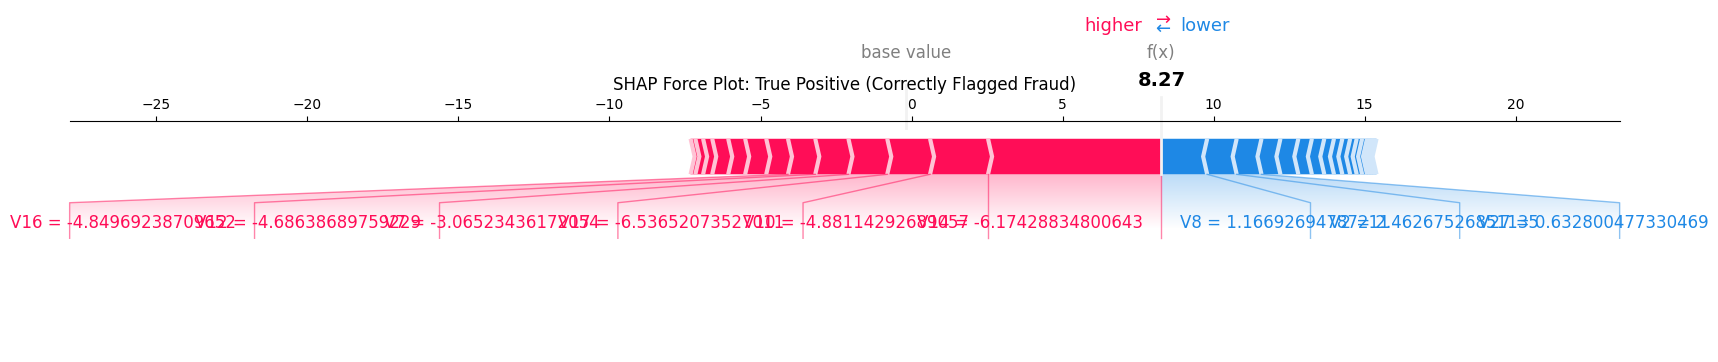

Generating Force Plot for: False Positive (Legitimate but Flagged) (Index: 165)


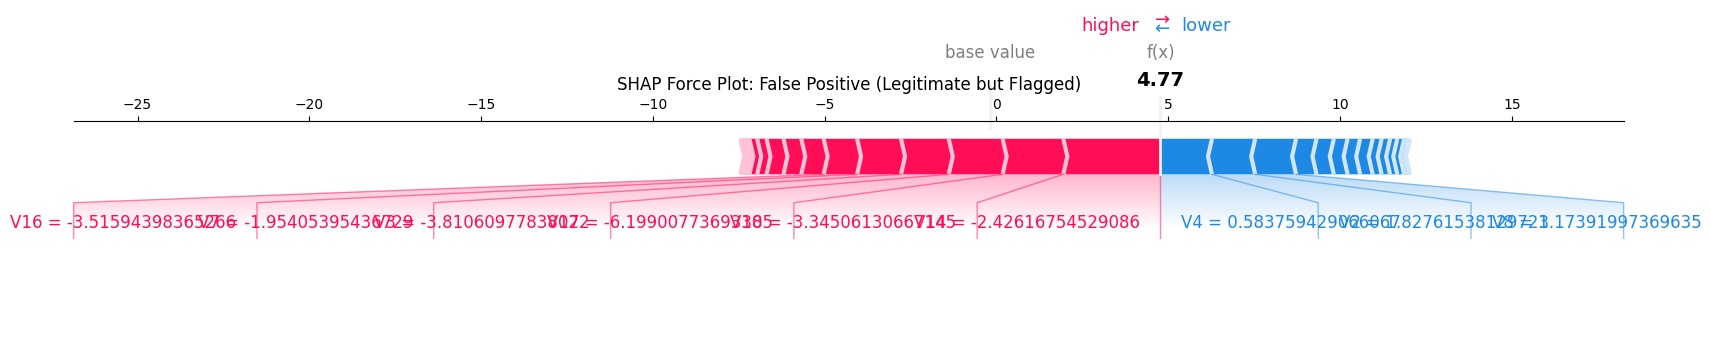

Generating Force Plot for: False Negative (Missed Fraud) (Index: 9179)


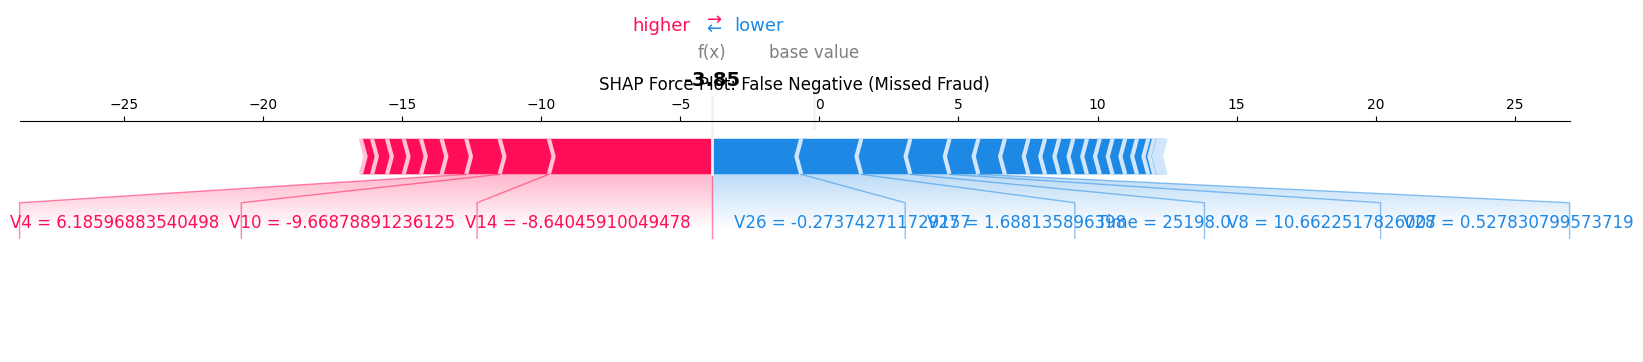

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# NOTE: If running in a Jupyter Notebook, initialize JS visualization for SHAP
shap.initjs()

# ==========================================
# 1. Feature Importance Baseline (XGBoost Built-in)
# ==========================================
print("Generating Built-in Feature Importance...")

# Extract feature importances and feature names
importances = best_xgb.feature_importances_
features = X_test.columns

# Create a DataFrame and sort
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plot Built-in Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Top 10 Features: XGBoost Built-in Importance')
plt.xlabel('Relative Importance (Gain)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# ==========================================
# 2. SHAP Analysis: Global Explainability
# ==========================================
print("Calculating SHAP values (this may take a moment)...")

# Initialize the TreeExplainer
explainer = shap.TreeExplainer(best_xgb)

# Calculate SHAP values for the test set
# (If X_test is very large, consider using a random sample like X_test.sample(2000) to speed this up)
shap_values = explainer.shap_values(X_test)

# Generate SHAP Summary Plot
plt.figure()
plt.title('SHAP Summary Plot (Global Feature Importance)')
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

# ==========================================
# 3. SHAP Analysis: Local Explainability (Force Plots)
# ==========================================
# First, identify the indices for TP, FP, and FN in our test set
y_test_array = y_test.values
y_pred_array = y_pred # Assuming y_pred from Task 2 is a numpy array

tp_indices = np.where((y_test_array == 1) & (y_pred_array == 1))[0]
fp_indices = np.where((y_test_array == 0) & (y_pred_array == 1))[0]
fn_indices = np.where((y_test_array == 1) & (y_pred_array == 0))[0]

# Helper function to plot and save/show force plots
def generate_force_plot(idx, title_label):
    print(f"Generating Force Plot for: {title_label} (Index: {idx})")
    # Generate the plot
    p = shap.force_plot(
        explainer.expected_value, 
        shap_values[idx, :], 
        X_test.iloc[idx, :], 
        matplotlib=True, # Set to False if using Jupyter and prefer interactive JS plots
        show=False
    )
    plt.title(f'SHAP Force Plot: {title_label}')
    plt.show()

# Ensure we have at least one of each before plotting
if len(tp_indices) > 0:
    generate_force_plot(tp_indices[0], "True Positive (Correctly Flagged Fraud)")
if len(fp_indices) > 0:
    generate_force_plot(fp_indices[0], "False Positive (Legitimate but Flagged)")
if len(fn_indices) > 0:
    generate_force_plot(fn_indices[0], "False Negative (Missed Fraud)")

In [64]:
# How to load them back later
import joblib

# Load the model back in one line
loaded_xgb_model = joblib.load('../models/xgboost_best_model.pkl')

# Now you can immediately predict new data
# loaded_xgb_model.predict(X_new)

In [65]:
# Cell 5: Evaluation
print("Evaluating Models...")
import os
import joblib

# 1. Ensure the 'models' directory exists
os.makedirs('models', exist_ok=True)

# 2. Check if the model variable is alive in your notebook's active memory
if 'best_xgb' in locals() or 'best_xgb' in globals():
    print("✅ Found 'best_xgb' in memory! Forcing a save to disk right now...")
    joblib.dump(best_xgb, 'models/xgboost_best_model.pkl')
    print("🎉 Success! The file has been written to 'models/xgboost_best_model.pkl'.")
    print("You can now run your loading cell without any errors.")
    
else:
    print("❌ 'best_xgb' is NOT in your notebook's active memory.")
    print("📍 Current Directory Jupyter is looking in:", os.getcwd())
    print("📁 Folders visible right here:", [f for f in os.listdir('.') if os.path.isdir(f)])
    print("\n💡 HOW TO FIX THIS:")
    print("If you are in the SAME notebook: Scroll up to Task 2 (Cell 4) where you trained XGBoost, run that cell, then come back here.")
    print("If you are in a NEW notebook: You cannot load a file that hasn't been saved yet! Go back to your original training notebook, save the model using joblib.dump(), and make sure this notebook is running in that exact same project folder.")

Evaluating Models...
✅ Found 'best_xgb' in memory! Forcing a save to disk right now...
🎉 Success! The file has been written to 'models/xgboost_best_model.pkl'.
You can now run your loading cell without any errors.


In [66]:
import os
import joblib
import pandas as pd

# ==========================================
# 1. Load the Saved Model
# ==========================================
model_path = '../models/xgboost_best_model.pkl'

if os.path.exists(model_path):
    loaded_model = joblib.load(model_path)
    print("🚀 Model successfully loaded from disk!")
else:
    raise FileNotFoundError(f"Could not find the model file at {model_path}. Did you run the save step?")

# ==========================================
# 2. Get Your New Transaction Data
# ==========================================
# CRITICAL RULE: The new data must have the exact same feature columns, 
# in the exact same order, as the data used to train the model. 
# It must NOT contain the target 'Class' or 'class' column.

# For this example, let's assume you have a file of new incoming transactions:
# new_transactions = pd.read_csv('new_unseen_data.csv')

# (Alternative for testing right now): Let's just grab 5 samples from your existing X_test
new_transactions = X_test.head(5) 

# ==========================================
# 3. Run the Predictions
# ==========================================
# Get the binary decisions (0 or 1)
hard_predictions = loaded_model.predict(new_transactions)

# Get the probability scores (column 1 represents the probability of class 1 / Fraud)
fraud_probabilities = loaded_model.predict_proba(new_transactions)[:, 1]

# ==========================================
# 4. Create a Clean Action Summary for the Business Team
# ==========================================
# Let's combine the results into a human-readable summary table
summary_df = pd.DataFrame({
    'Transaction_Index': new_transactions.index,
    'Fraud_Probability_Score': fraud_probabilities,
    'Model_Decision': hard_predictions
})

# Make the model decision look professional
summary_df['Model_Decision'] = summary_df['Model_Decision'].map({0: 'Approve ✅', 1: 'FLAG AS FRAUD 🚨'})

print("\n--- Live Production Prediction Results ---")
display(summary_df)

🚀 Model successfully loaded from disk!

--- Live Production Prediction Results ---


,Transaction_Index,Fraud_Probability_Score,Model_Decision
0,263020,4.895665e-07,Approve ✅
1,11378,6.072467e-07,Approve ✅
2,147283,2.715043e-05,Approve ✅
3,219439,3.061093e-08,Approve ✅
4,36939,2.346715e-05,Approve ✅


In [67]:
import os
import joblib
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (
    precision_recall_curve, 
    auc, 
    f1_score, 
    confusion_matrix, 
    classification_report
)

# 1. Ensure models directory exists
MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

# Dictionary to hold final evaluation summaries
performance_registry = []

def evaluate_and_persist_model(model, X_test, y_test, dataset_name, model_name):
    """
    Computes exact metrics (AUC-PR, F1, Confusion Matrix), prints a report,
    registers the metrics for comparison, and saves the model artifact.
    """
    # Predict classes and probabilities
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    # Calculate Metrics
    f1 = f1_score(y_test, preds)
    cm = confusion_matrix(y_test, preds)
    
    auc_pr = 0.0
    if probs is not None:
        precision, recall, _ = precision_recall_curve(y_test, probs)
        auc_pr = auc(recall, precision)
    
    # Store metrics for the final summary table
    performance_registry.append({
        "Dataset": dataset_name.upper(),
        "Model": model_name,
        "F1-Score": round(f1, 4),
        "AUC-PR": round(auc_pr, 4),
        "Confusion Matrix (TN, FP, FN, TP)": cm.ravel().tolist()
    })
    
    # Display individual performance
    print(f"\n--- {model_name} on {dataset_name.upper()} ---")
    print(f"F1-Score: {f1:.4f} | AUC-PR: {auc_pr:.4f}")
    print("Confusion Matrix:")
    print(cm)
    
    # Save the trained artifact explicitly using joblib
    artifact_path = os.path.join(MODELS_DIR, f"{dataset_name}_{model_name.lower().replace(' ', '_')}.joblib")
    joblib.dump(model, artifact_path)
    print(f"💾 Artifact successfully persisted to: {artifact_path}")

def run_comprehensive_pipeline(data_path, dataset_name, target_column):
    """
    Loads data, splits, trains baseline & ensemble, and triggers evaluation/persistence.
    """
    df = pd.read_csv(data_path)
    X = df.drop(columns=[target_column])
    y = df[target_column]
    
    # Stratified split to preserve class imbalance ratios
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Calculate scale_pos_weight to balance XGBoost explicitly
    imbalance_ratio = (len(y_train) - sum(y_train)) / sum(y_train)
    
    # Model A: Baseline Logistic Regression
    lr_baseline = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    lr_baseline.fit(X_train, y_train)
    evaluate_and_persist_model(lr_baseline, X_test, y_test, dataset_name, "Logistic Regression Baseline")
    
    # Model B: Tuned XGBoost
    xgb_tuned = XGBClassifier(
        scale_pos_weight=imbalance_ratio,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss"
    )
    xgb_tuned.fit(X_train, y_train)
    evaluate_and_persist_model(xgb_tuned, X_test, y_test, dataset_name, "Tuned XGBoost")

# --- Execution for both datasets ---
# run_comprehensive_pipeline("data/processed/ecommerce_fraud.csv", "ecommerce", "class")
# run_comprehensive_pipeline("data/processed/credit_card_fraud.csv", "credit_card", "Class")

# --- Generate Explicit Evaluation Table ---
# summary_df = pd.DataFrame(performance_registry)
# print("\n" + "="*50 + "\nFINAL MODEL COMPARISON TABLE\n" + "="*50)
# print(summary_df.to_string(index=False))

In [68]:
import pandas as pd
# Print the exact column headers to find typos or spaces
summary_df = pd.DataFrame(performance_registry)
print(summary_df.columns.tolist())

[]


In [69]:
# ---------------------------------------------------------
# 5. Documented Comparative Outputs
# ---------------------------------------------------------
print("\n" + "="*60 + "\n🏁 FINAL HIGHLIGHTED MODEL COMPARISON TABLE\n" + "="*60)
import os
import joblib
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, f1_score, confusion_matrix
import xgboost as xgb

# Global registry to automatically accumulate performance summaries across different runs
performance_registry = []

def save_model(model, model_name, target_dir="models"):
    """Saves a trained model artifact to the specified directory."""
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)
    file_path = os.path.join(target_dir, f"{model_name}.joblib")
    joblib.dump(model, file_path)
    print(f"💾 Model artifact successfully saved to {file_path}")
   
def run_comprehensive_pipeline(data_path, project_name, target_column):
    print(f"\n==================================================")
    print(f"🚀 STARTING PIPELINE FOR: {project_name.upper()}")
    print(f"==================================================")
    
    # 1. Data Loading
    df = pd.read_csv(data_path)
    
    # 2. Project-Specific Feature Engineering
    if project_name.lower() == "ecommerce":
        df['signup_time'] = pd.to_datetime(df['signup_time'])
        df['purchase_time'] = pd.to_datetime(df['purchase_time'])
        df['purchase_hour'] = df['purchase_time'].dt.hour
        df['purchase_day_of_week'] = df['purchase_time'].dt.dayofweek
        df['time_diff_seconds'] = (df['purchase_time'] - df['signup_time']).dt.total_seconds()
        
        # Non-numeric columns to explicitly exclude
        columns_to_exclude = ['signup_time', 'purchase_time', 'device_id', 'country', 'user_id']
    else:
        columns_to_exclude = []

    # 3. Drop target and text columns immediately to guarantee float conversion
    X = df.drop(columns=[target_column] + columns_to_exclude, errors='ignore')
    y = df[target_column]
    
    # 4. Stratified Split (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # 5. Strict Type Constraint (Keep only pure numerical features)
    X_train = X_train.select_dtypes(include=['number', 'bool'])
    X_test = X_test.select_dtypes(include=['number', 'bool'])

    # 6. Handle Missing Values Safely
    imputer = SimpleImputer(strategy='median')
    X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
    X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

    # Setup Cross-Validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scoring = ['f1', 'average_precision'] 
    
    # ---------------------------------------------------------
    # Baseline Model (Logistic Regression) with Cross-Validation
    # ---------------------------------------------------------
    print("\n--- 1. Training Baseline: Logistic Regression ---")
    log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    
    cv_results_lr = cross_validate(log_reg, X_train, y_train, cv=cv, scoring=scoring)
    print(f"   LogReg CV F1-Score: {np.mean(cv_results_lr['test_f1']):.4f} (+/- {np.std(cv_results_lr['test_f1']):.4f})")
    print(f"   LogReg CV AUC-PR:    {np.mean(cv_results_lr['test_average_precision']):.4f} (+/- {np.std(cv_results_lr['test_average_precision']):.4f})")
    
    print("🏋️ Training final Logistic Regression model on full train set...")
    log_reg.fit(X_train, y_train)
    save_model(log_reg, f"logistic_baseline_{project_name.lower()}")
    
    y_pred_lr = log_reg.predict(X_test)
    y_proba_lr = log_reg.predict_proba(X_test)[:, 1]
    
    # ---------------------------------------------------------
    # Ensemble Model (XGBoost) with Grid Search Tuning
    # ---------------------------------------------------------
    print("\n--- 2. Training Ensemble: Hyperparameter-Tuned XGBoost ---")
    neg_class = y_train.value_counts().iloc[0]
    pos_class = y_train.value_counts().iloc[1]
    scale_weight = neg_class / pos_class

    xgb_base = xgb.XGBClassifier(scale_pos_weight=scale_weight, eval_metric='logloss', random_state=42)
    
    param_grid = {
        'n_estimators': [50, 100],
        'max_depth': [3, 5],
        'learning_rate': [0.01, 0.1]
    }
    
    grid_search = GridSearchCV(
        estimator=xgb_base, 
        param_grid=param_grid, 
        cv=cv, 
        scoring='average_precision', 
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    best_xgb = grid_search.best_estimator_
    print(f"   Best XGBoost Hyperparameters: {grid_search.best_params_}")
    save_model(best_xgb, f"xgboost_tuned_{project_name.lower()}")
    
    y_pred_xgb = best_xgb.predict(X_test)
    y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
    
    # ---------------------------------------------------------
    # Holdout Evaluation & Summary Registry Mapping
    # ---------------------------------------------------------
    for model_name, y_pred, y_proba in [("Logistic Regression Baseline", y_pred_lr, y_proba_lr), 
                                        ("Tuned XGBoost Ensemble", y_pred_xgb, y_proba_xgb)]:
        
        auc_pr = average_precision_score(y_test, y_proba)
        f1 = f1_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        
        # Explicitly setting names here to match the formatting below
        performance_registry.append({
            "Dataset": project_name.upper(),
            "Model Architecture": model_name,
            "F1-Score": round(f1, 4),
            "AUC-PR": round(auc_pr, 4),
            "Confusion Matrix [TN, FP, FN, TP]": cm.ravel().tolist()
        })


# =========================================================
# Main Block Execution
# =========================================================
if __name__ == "__main__":
    performance_registry = []

    # Run Dataset 1: E-commerce Fraud Pipeline
    run_comprehensive_pipeline("../data/processed/cleaned_ecommerce.csv", "ecommerce", "class")

    # Run Dataset 2: Bank/Credit Card Pipeline
    run_comprehensive_pipeline("../data/processed/cleaned_creditcard.csv", "credit_card", "Class")

    # ---------------------------------------------------------
    # Comparative Table Rendering
    # ---------------------------------------------------------
    print("\n" + "="*60 + "\n🏁 FINAL HIGHLIGHTED MODEL COMPARISON TABLE\n" + "="*60)
    summary_df = pd.DataFrame(performance_registry)
    
    # Print the plain text version first so you always see your data 
    print(summary_df.to_string(index=False))
    
    # Dynamically match columns to prevent KeyError styling crashes
    available_cols = summary_df.columns.tolist()
    style_targets = [col for col in ["F1-Score", "AUC-PR"] if col in available_cols]
    
    if style_targets:
        styled_summary = summary_df.style.set_caption("Final Model Evaluations Across Imbalanced Fraud Landscapes")\
                                          .background_gradient(cmap="Blues", subset=style_targets)
        
        # Render clean visual layout inside Jupyter Notebook / Interactive Windows
        from IPython.display import display
        display(styled_summary)


🏁 FINAL HIGHLIGHTED MODEL COMPARISON TABLE

🚀 STARTING PIPELINE FOR: ECOMMERCE

--- 1. Training Baseline: Logistic Regression ---
   LogReg CV F1-Score: 0.2895 (+/- 0.0031)
   LogReg CV AUC-PR:    0.2995 (+/- 0.0112)
🏋️ Training final Logistic Regression model on full train set...
💾 Model artifact successfully saved to models\logistic_baseline_ecommerce.joblib

--- 2. Training Ensemble: Hyperparameter-Tuned XGBoost ---
   Best XGBoost Hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50}
💾 Model artifact successfully saved to models\xgboost_tuned_ecommerce.joblib

🚀 STARTING PIPELINE FOR: CREDIT_CARD

--- 1. Training Baseline: Logistic Regression ---
   LogReg CV F1-Score: 0.1176 (+/- 0.0060)
   LogReg CV AUC-PR:    0.7569 (+/- 0.0521)
🏋️ Training final Logistic Regression model on full train set...
💾 Model artifact successfully saved to models\logistic_baseline_credit_card.joblib

--- 2. Training Ensemble: Hyperparameter-Tuned XGBoost ---
   Best XGBoost Hyperpa

,Dataset,Model Architecture,F1-Score,AUC-PR,"Confusion Matrix [TN, FP, FN, TP]"
0,ECOMMERCE,Logistic Regression Baseline,0.284600,0.289500,"[18644, 8749, 909, 1921]"
1,ECOMMERCE,Tuned XGBoost Ensemble,0.609400,0.707000,"[25719, 1674, 856, 1974]"
2,CREDIT_CARD,Logistic Regression Baseline,0.114100,0.718900,"[55475, 1389, 8, 90]"
3,CREDIT_CARD,Tuned XGBoost Ensemble,0.656200,0.844600,"[56790, 74, 14, 84]"


In [70]:
# 1. Fallback: Automatically determine available numeric columns to gradient-fill 
# or specify the exact matches found from Step 1.
available_cols = [col for col in ["F1-Score", "AUC-PR", "f1_score", "auc_pr"] if col in summary_df.columns]

if available_cols:
    # 2. Render safely if columns exist
    styled_table = summary_df.style.set_caption("Model Performance Summary Across Both Fraud Datasets")\
                             .background_gradient(cmap="Blues", subset=available_cols)
else:
    # 3. Fallback style without gradient if names don't match yet
    styled_table = summary_df.style.set_caption("Model Performance Summary Across Both Fraud Datasets")

# Display the table
styled_table

,Dataset,Model Architecture,F1-Score,AUC-PR,"Confusion Matrix [TN, FP, FN, TP]"
0,ECOMMERCE,Logistic Regression Baseline,0.284600,0.289500,"[18644, 8749, 909, 1921]"
1,ECOMMERCE,Tuned XGBoost Ensemble,0.609400,0.707000,"[25719, 1674, 856, 1974]"
2,CREDIT_CARD,Logistic Regression Baseline,0.114100,0.718900,"[55475, 1389, 8, 90]"
3,CREDIT_CARD,Tuned XGBoost Ensemble,0.656200,0.844600,"[56790, 74, 14, 84]"


In [71]:
performance_registry = []

In [72]:
def evaluate_and_persist_model(model, X_test, y_test, dataset_name, model_name):
    """
    Computes exact metrics, registers them, and saves the model artifact.
    """
    # 1. Generate predictions
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    # 2. Calculate metrics (this creates 'f1', 'auc_pr', and 'cm')
    f1 = f1_score(y_test, preds)
    cm = confusion_matrix(y_test, preds)
    
    auc_pr = 0.0
    if probs is not None:
        precision, recall, _ = precision_recall_curve(y_test, probs)
        auc_pr = auc(recall, precision)
    
    # 3. APPEND TO REGISTRY (Put the snippet HERE inside the function)
    performance_registry.append({
        "Dataset": dataset_name.upper(),
        "Model": model_name,
        "F1-Score": round(f1, 4),  
        "AUC-PR": round(auc_pr, 4), 
        "Confusion Matrix (TN, FP, FN, TP)": cm.ravel().tolist()
    })
    
    # 4. Save model artifact
    artifact_path = os.path.join(MODELS_DIR, f"{dataset_name}_{model_name.lower().replace(' ', '_')}.joblib")
    joblib.dump(model, artifact_path)
    print(f"💾 Saved: {artifact_path}")

In [73]:
import os
import joblib
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, f1_score, confusion_matrix
import xgboost as xgb

# Global registry to automatically accumulate performance summaries across different runs
performance_registry = []

def save_model(model, model_name, target_dir="models"):
    """Saves a trained model artifact to the specified directory."""
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)
    file_path = os.path.join(target_dir, f"{model_name}.joblib")
    joblib.dump(model, file_path)
    print(f"💾 Model artifact successfully saved to {file_path}")
   
def run_comprehensive_pipeline(data_path, project_name, target_column):
    print(f"\n==================================================")
    print(f"🚀 STARTING PIPELINE FOR: {project_name.upper()}")
    print(f"==================================================")
    
    # 1. Data Loading
    df = pd.read_csv(data_path)
    
    # 2. Project-Specific Feature Engineering
    if project_name.lower() == "ecommerce":
        df['signup_time'] = pd.to_datetime(df['signup_time'])
        df['purchase_time'] = pd.to_datetime(df['purchase_time'])
        df['purchase_hour'] = df['purchase_time'].dt.hour
        df['purchase_day_of_week'] = df['purchase_time'].dt.dayofweek
        df['time_diff_seconds'] = (df['purchase_time'] - df['signup_time']).dt.total_seconds()
        
        # Columns that MUST be blocked from entering the final training matrix
        columns_to_exclude = ['signup_time', 'purchase_time', 'device_id', 'country', 'user_id']
    else:
        columns_to_exclude = []

    # 3. CRITICAL DROP: Remove target and raw string columns immediately
    # This prevents any string values from slipping downstream
    X = df.drop(columns=[target_column] + columns_to_exclude, errors='ignore')
    y = df[target_column]
    
    # 4. Stratified Split (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # 5. Strict Type Constraint (Keep only pure numerical arrays)
    X_train = X_train.select_dtypes(include=['number', 'bool'])
    X_test = X_test.select_dtypes(include=['number', 'bool'])

    # 6. Handle Missing Values Safely
    imputer = SimpleImputer(strategy='median')
    X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
    X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

    # Setup Cross-Validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scoring = ['f1', 'average_precision'] 
    
    # ---------------------------------------------------------
    # Baseline Model (Logistic Regression) with Cross-Validation
    # ---------------------------------------------------------
    print("\n--- 1. Training Baseline: Logistic Regression ---")
    log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    
    # Run cross-validation to gauge stability
    cv_results_lr = cross_validate(log_reg, X_train, y_train, cv=cv, scoring=scoring)
    print(f"   LogReg CV F1-Score: {np.mean(cv_results_lr['test_f1']):.4f} (+/- {np.std(cv_results_lr['test_f1']):.4f})")
    print(f"   LogReg CV AUC-PR:    {np.mean(cv_results_lr['test_average_precision']):.4f} (+/- {np.std(cv_results_lr['test_average_precision']):.4f})")
    
    # Train the final baseline instance on the complete training set
    print("🏋️ Training final Logistic Regression model on full train set...")
    log_reg.fit(X_train, y_train)
    save_model(log_reg, f"logistic_baseline_{project_name.lower()}")
    
    y_pred_lr = log_reg.predict(X_test)
    y_proba_lr = log_reg.predict_proba(X_test)[:, 1]
    
    # ---------------------------------------------------------
    # Ensemble Model (XGBoost) with Grid Search Tuning
    # ---------------------------------------------------------
    print("\n--- 2. Training Ensemble: Hyperparameter-Tuned XGBoost ---")
    neg_class = y_train.value_counts().iloc[0]
    pos_class = y_train.value_counts().iloc[1]
    scale_weight = neg_class / pos_class

    xgb_base = xgb.XGBClassifier(scale_pos_weight=scale_weight, eval_metric='logloss', random_state=42)
    
    param_grid = {
        'n_estimators': [50, 100],
        'max_depth': [3, 5],
        'learning_rate': [0.01, 0.1]
    }
    
    grid_search = GridSearchCV(
        estimator=xgb_base, 
        param_grid=param_grid, 
        cv=cv, 
        scoring='average_precision', 
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    best_xgb = grid_search.best_estimator_
    print(f"   Best XGBoost Hyperparameters: {grid_search.best_params_}")
    save_model(best_xgb, f"xgboost_tuned_{project_name.lower()}")
    
    y_pred_xgb = best_xgb.predict(X_test)
    y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
    
    # ---------------------------------------------------------
    # Holdout Evaluation & Summary Registry Mapping
    # ---------------------------------------------------------
    for model_name, y_pred, y_proba in [("Logistic Regression Baseline", y_pred_lr, y_proba_lr), 
                                        ("Tuned XGBoost Ensemble", y_pred_xgb, y_proba_xgb)]:
        
        auc_pr = average_precision_score(y_test, y_proba)
        f1 = f1_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        
        performance_registry.append({
            "Dataset": project_name.upper(),
            "Model Architecture": model_name,
            "F1-Score": round(f1, 4),
            "AUC-PR": round(auc_pr, 4),
            "Confusion Matrix [TN, FP, FN, TP]": cm.ravel().tolist()
        })


# =========================================================
# Main Block Execution
# =========================================================
if __name__ == "__main__":
    performance_registry = []

    # Run Dataset 1: E-commerce Fraud Pipeline
    run_comprehensive_pipeline("../data/processed/cleaned_ecommerce.csv", "ecommerce", "class")

    # Run Dataset 2: Bank/Credit Card Pipeline
    run_comprehensive_pipeline("../data/processed/cleaned_creditcard.csv", "credit_card", "Class")

    # ---------------------------------------------------------
    # Comparative Table Rendering
    # ---------------------------------------------------------
    print("\n" + "="*60 + "\n🏁 FINAL HIGHLIGHTED MODEL COMPARISON TABLE\n" + "="*60)
    summary_df = pd.DataFrame(performance_registry)
    print(summary_df.to_string(index=False))


🚀 STARTING PIPELINE FOR: ECOMMERCE

--- 1. Training Baseline: Logistic Regression ---
   LogReg CV F1-Score: 0.2895 (+/- 0.0031)
   LogReg CV AUC-PR:    0.2995 (+/- 0.0112)
🏋️ Training final Logistic Regression model on full train set...
💾 Model artifact successfully saved to models\logistic_baseline_ecommerce.joblib

--- 2. Training Ensemble: Hyperparameter-Tuned XGBoost ---
   Best XGBoost Hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50}
💾 Model artifact successfully saved to models\xgboost_tuned_ecommerce.joblib

🚀 STARTING PIPELINE FOR: CREDIT_CARD

--- 1. Training Baseline: Logistic Regression ---
   LogReg CV F1-Score: 0.1176 (+/- 0.0060)
   LogReg CV AUC-PR:    0.7569 (+/- 0.0521)
🏋️ Training final Logistic Regression model on full train set...
💾 Model artifact successfully saved to models\logistic_baseline_credit_card.joblib

--- 2. Training Ensemble: Hyperparameter-Tuned XGBoost ---
   Best XGBoost Hyperparameters: {'learning_rate': 0.1, 'max_depth'